# Análise da referência histórica

## Objetivo

Avaliar o histórico disponível de SRAG para Minas Gerais e identificar
uma referência adequada para comparação da série epidemiológica de 2026.

A análise busca responder:

1. Quantos anos históricos comparáveis estão disponíveis?
2. Existe padrão sazonal ao longo das semanas epidemiológicas?
3. Quais anos ou períodos apresentam comportamento atípico?
4. Qual quantidade mínima de histórico é necessária para construir a referência?
5. Qual método inicial de comparação é adequado aos dados disponíveis?

A decisão metodológica resultante será registrada em `docs/decisions.md`.

In [1]:
import pandas as pd

from pathlib import Path

project_root = Path.cwd().parent
raw_dir = project_root / "data" / "raw"

historical_files = sorted(raw_dir.glob("INFLUD*.csv"))

print(f"Arquivos encontrados: {len(historical_files)}")

for path in historical_files:
    print(f"- {path.name}")

Arquivos encontrados: 8
- INFLUD19-23-03-2026.csv
- INFLUD20-23-03-2026.csv
- INFLUD21-23-03-2026.csv
- INFLUD22-23-03-2026.csv
- INFLUD23-23-03-2026.csv
- INFLUD24-23-03-2026.csv
- INFLUD25-28-09-2026.csv
- INFLUD26-28-09-2026.csv


In [2]:
assert len(historical_files) == 8, (
    f"Esperados 8 arquivos INFLUD, encontrados {len(historical_files)}"
)

expected_years = {str(year)[-2:] for year in range(2019, 2027)}

found_years = {
    path.name.upper().split("INFLUD")[1][:2]
    for path in historical_files
}

assert found_years == expected_years, (
    f"Anos encontrados: {sorted(found_years)}; "
    f"esperados: {sorted(expected_years)}"
)

print("✓ Arquivos de 2019 a 2026 encontrados.")

✓ Arquivos de 2019 a 2026 encontrados.


In [3]:
schema_audit = []

for path in historical_files:
    df_header = pd.read_csv(
        path,
        sep=";",
        encoding="latin-1",
        nrows=0,
    )

    year = int(f"20{path.name.upper().split('INFLUD')[1][:2]}")

    schema_audit.append(
        {
            "year": year,
            "file": path.name,
            "column_count": len(df_header.columns),
            "has_dt_sin_pri": "DT_SIN_PRI" in df_header.columns,
            "has_sg_uf_not": "SG_UF_NOT" in df_header.columns,
            "has_sem_pri": "SEM_PRI" in df_header.columns,
        }
    )

schema_audit_dif = pd.DataFrame(schema_audit).sort_values("year")

display(schema_audit_dif)

,year,file,column_count,has_dt_sin_pri,has_sg_uf_not,has_sem_pri
0,2019,INFLUD19-23-03-2026.csv,194,True,True,True
1,2020,INFLUD20-23-03-2026.csv,194,True,True,True
2,2021,INFLUD21-23-03-2026.csv,194,True,True,True
3,2022,INFLUD22-23-03-2026.csv,194,True,True,True
4,2023,INFLUD23-23-03-2026.csv,194,True,True,True
5,2024,INFLUD24-23-03-2026.csv,194,True,True,True
6,2025,INFLUD25-28-09-2026.csv,194,True,True,True
7,2026,INFLUD26-28-09-2026.csv,194,True,True,True


## Auditoria da cobertura histórica

Após confirmar a compatibilidade estrutural dos arquivos de 2019 a 2026,
será avaliada a cobertura temporal de cada ano.

Para cada arquivo serão verificados:

- quantidade total de registros;
- quantidade de registros de Minas Gerais;
- primeira e última data de início dos sintomas;
- quantidade de datas de início dos sintomas ausentes;
- semanas epidemiológicas presentes;
- consistência entre a semana informada pela fonte e a data de início dos sintomas.

Essa auditoria será utilizada para determinar quais anos possuem dados
suficientes e comparáveis para compor a referência histórica.

In [4]:
audit_frames = []

usecols = [
    "DT_SIN_PRI",
    "SEM_PRI",
    "SG_UF",
]

for path in historical_files:
    year = int(f"20{path.name.upper().split('INFLUD')[1][:2]}")

    df = pd.read_csv(
        path,
        sep=";",
        encoding="latin-1",
        usecols=usecols,
        dtype="string",
        low_memory=False,
    )

    total_records = len(df)

    residence_uf = (
        df["SG_UF"]
        .str.strip()
        .str.upper()
    )

    mg_df = df.loc[residence_uf == "MG"].copy()

    symptom_dates = pd.to_datetime(
        mg_df["DT_SIN_PRI"],
        errors="coerce",
        utc=True,
    )

    epi_weeks = pd.to_numeric(
        mg_df["SEM_PRI"],
        errors="coerce",
    )

    audit_frames.append(
        {
            "year": year,
            "file": path.name,
            "total_records": total_records,
            "mg_records": len(mg_df),
            "first_symptom_date": symptom_dates.min(),
            "last_symptom_date": symptom_dates.max(),
            "missing_symptom_dates": int(symptom_dates.isna().sum()),
            "first_epi_week": epi_weeks.min(),
            "last_epi_week": epi_weeks.max(),
            "unique_epi_weeks": epi_weeks.nunique(),
        }
    )

historical_coverage = (
    pd.DataFrame(audit_frames)
    .sort_values("year")
    .reset_index(drop=True)
)

display(historical_coverage)

,year,file,total_records,mg_records,first_symptom_date,last_symptom_date,missing_symptom_dates,first_epi_week,last_epi_week,unique_epi_weeks
0,2019,INFLUD19-23-03-2026.csv,48941,4035,2018-12-30 00:00:00+00:00,2019-12-28 00:00:00+00:00,0,1,52,52
1,2020,INFLUD20-23-03-2026.csv,1206920,113781,2019-12-29 00:00:00+00:00,2021-01-02 00:00:00+00:00,0,1,53,53
2,2021,INFLUD21-23-03-2026.csv,1745672,209248,2021-01-03 00:00:00+00:00,2022-01-01 00:00:00+00:00,0,1,52,52
3,2022,INFLUD22-23-03-2026.csv,560577,69332,2022-01-02 00:00:00+00:00,2022-12-31 00:00:00+00:00,0,1,52,52
4,2023,INFLUD23-23-03-2026.csv,279453,25613,2023-01-01 00:00:00+00:00,2023-12-30 00:00:00+00:00,0,1,52,52
5,2024,INFLUD24-23-03-2026.csv,267986,27271,2023-12-31 00:00:00+00:00,2024-12-28 00:00:00+00:00,0,1,52,52
6,2025,INFLUD25-28-09-2026.csv,336420,45655,2024-12-29 00:00:00+00:00,2026-01-03 00:00:00+00:00,0,1,52,52
7,2026,INFLUD26-28-09-2026.csv,220941,29087,2026-01-04 00:00:00+00:00,2026-09-26 00:00:00+00:00,0,2,39,38


## Séries históricas semanais

Para avaliar a sazonalidade, os registros de residentes de Minas Gerais
são agrupados pela semana epidemiológica de início dos sintomas.

Os anos de 2019 a 2025 são inicialmente mantidos sem exclusões para
permitir a inspeção visual e quantitativa do comportamento histórico.

O ano de 2026 é mantido separadamente como série corrente e não participa
do cálculo de uma eventual referência histórica.

In [5]:
weekly_frames = []

for path in historical_files:
    year = int(f"20{path.name.upper().split('INFLUD')[1][:2]}")

    df = pd.read_csv(
        path,
        sep=";",
        encoding="latin-1",
        usecols=["SG_UF", "SEM_PRI"],
        dtype="string",
        low_memory=False,
    )

    residence_uf = (
        df["SG_UF"]
        .str.strip()
        .str.upper()
    )

    mg_df = df.loc[residence_uf == "MG"].copy()

    mg_df["epi_week"] = pd.to_numeric(
        mg_df["SEM_PRI"],
        errors="raise",
    ).astype("int64")

    weekly = (
        mg_df
        .groupby("epi_week")
        .size()
        .rename("record_count")
        .reset_index()
    )

    weekly.insert(0, "epi_year", year)

    weekly_frames.append(weekly)

historical_weekly = (
    pd.concat(
        weekly_frames,
        ignore_index=True,
    )
    .sort_values(["epi_year", "epi_week"])
    .reset_index(drop=True)
)

display(historical_weekly.head(10))

,epi_year,epi_week,record_count
0,2019,1,48
1,2019,2,48
2,2019,3,31
3,2019,4,21
4,2019,5,31
5,2019,6,31
6,2019,7,33
7,2019,8,31
8,2019,9,58
9,2019,10,46


In [6]:
assert historical_weekly["record_count"].sum() == historical_coverage[
    "mg_records"
].sum()

assert not historical_weekly.duplicated(
    ["epi_year", "epi_week"]
).any()

records_by_year = (
    historical_weekly
    .groupby("epi_year")["record_count"]
    .sum()
)

expected_by_year = (
    historical_coverage
    .set_index("year")["mg_records"]
)

pd.testing.assert_series_equal(
    records_by_year,
    expected_by_year,
    check_names=False,
)

print("✓ Séries semanais conferem com a auditoria histórica.")

✓ Séries semanais conferem com a auditoria histórica.


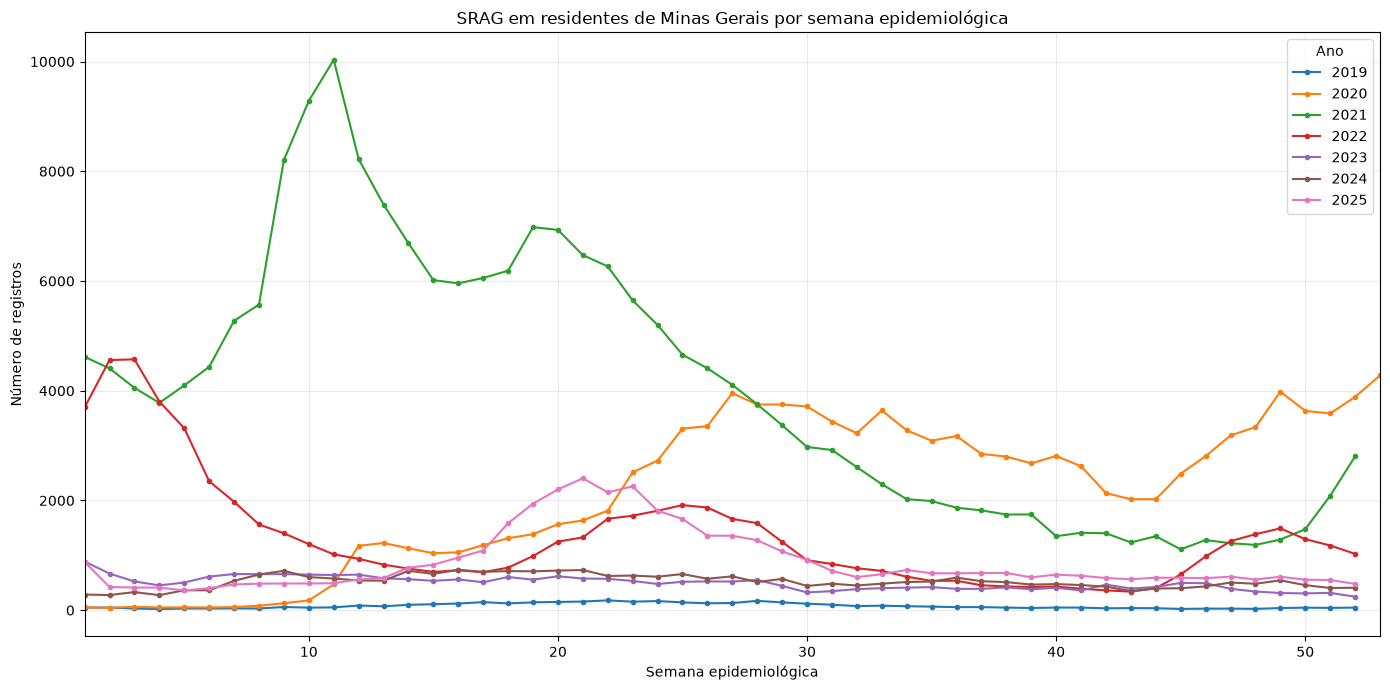

In [7]:
import matplotlib.pyplot as plt

historical_complete = historical_weekly.loc[
    historical_weekly["epi_year"].between(2019, 2025)
]

fig, ax = plt.subplots(figsize=(14, 7))

for year, group in historical_complete.groupby("epi_year"):
    ax.plot(
        group["epi_week"],
        group["record_count"],
        marker="o",
        markersize=3,
        linewidth=1.5,
        label=str(year),
    )

ax.set_title(
    "SRAG em residentes de Minas Gerais por semana epidemiológica"
)
ax.set_xlabel("Semana epidemiológica")
ax.set_ylabel("Número de registros")
ax.set_xlim(1, 53)
ax.grid(alpha=0.25)
ax.legend(title="Ano")

plt.tight_layout()
plt.show()

In [12]:
year_summary = (
    historical_weekly
    .loc[historical_weekly["epi_year"].between(2019, 2025)]
    .groupby("epi_year")
    .agg(
        total_records=("record_count", "sum"),
        mean_weekly=("record_count", "mean"),
        median_weekly=("record_count", "median"),
        max_weekly=("record_count", "max"),
        min_weekly=("record_count", "min"),
    )
)

peak_idx = (
    historical_weekly
    .loc[historical_weekly["epi_year"].between(2019, 2025)]
    .groupby("epi_year")["record_count"]
    .idxmax()
)

peak_summary = (
    historical_weekly
    .loc[peak_idx, ["epi_year", "epi_week", "record_count"]]
    .set_index("epi_year")
    .rename(
        columns={
            "epi_week": "peak_week",
            "record_count": "peak_count",
        }
    )
)

year_summary = year_summary.join(peak_summary)

display(year_summary)

,total_records,mean_weekly,median_weekly,max_weekly,min_weekly,peak_week,peak_count
epi_year,,,,,,,
2019,4035,77.596154,56.0,179,21,22,179
2020,113781,2146.811321,2512.0,4278,43,53,4278
2021,209248,4024.000000,3916.0,10032,1109,11,10032
2022,69332,1333.307692,1022.0,4572,338,3,4572
2023,25613,492.557692,500.5,887,245,1,887
2024,27271,524.442308,517.0,735,274,16,735
2025,45655,877.980769,638.0,2404,359,21,2404


In [9]:
weekly_matrix = (
    historical_weekly
    .loc[historical_weekly["epi_year"].between(2019, 2025)]
    .pivot(
        index="epi_week",
        columns="epi_year",
        values="record_count",
    )
)

display(weekly_matrix.head())

epi_year,2019,2020,2021,2022,2023,2024,2025
epi_week,,,,,,,
1,48.0,53.0,4618.0,3696.0,887.0,285.0,879.0
2,48.0,43.0,4407.0,4559.0,667.0,276.0,422.0
3,31.0,63.0,4053.0,4572.0,524.0,330.0,413.0
4,21.0,49.0,3779.0,3803.0,452.0,274.0,412.0
5,31.0,53.0,4097.0,3317.0,504.0,363.0,359.0


In [10]:
year_correlation = weekly_matrix.corr(
    method="spearman"
)

display(
    year_correlation.round(2)
)

epi_year,2019,2020,2021,2022,2023,2024,2025
epi_year,,,,,,,
2019,1.00,0.21,0.55,0.03,0.23,0.68,0.84
2020,0.21,1.00,-0.54,-0.23,-0.74,-0.02,0.34
2021,0.55,-0.54,1.00,0.37,0.78,0.62,0.22
2022,0.03,-0.23,0.37,1.00,0.42,-0.01,-0.11
2023,0.23,-0.74,0.78,0.42,1.00,0.39,0.04
2024,0.68,-0.02,0.62,-0.01,0.39,1.00,0.61
2025,0.84,0.34,0.22,-0.11,0.04,0.61,1.00


## Avaliação do método de referência histórica

Como os anos históricos apresentam diferenças substanciais de magnitude
e padrão sazonal, uma média simples pode ser fortemente influenciada por
anos atípicos.

Como método inicial, será avaliada uma referência semanal baseada na
mediana histórica, acompanhada pelos percentis 25 e 75.

A referência é calculada separadamente para cada semana epidemiológica,
preservando a sazonalidade observada nos dados.

O ano de 2026 não participa do cálculo da referência histórica.

In [13]:
historical_reference = (
    historical_weekly
    .loc[
        historical_weekly["epi_year"].between(2019, 2025)
        & historical_weekly["epi_week"].between(1, 52)
    ]
    .groupby("epi_week")["record_count"]
    .agg(
       historical_min="min",
        q25=lambda x: x.quantile(0.25),
        historical_median="median",
        q75=lambda x: x.quantile(0.75),
        historical_max="max",
        historical_years="count", 
    )
    .reset_index()
)

display(historical_reference.head(10))

,epi_week,historical_min,q25,historical_median,q75,historical_max,historical_years
0,1,48,169.0,879.0,2291.5,4618,7
1,2,43,162.0,422.0,2537.0,4559,7
2,3,31,196.5,413.0,2288.5,4572,7
3,4,21,161.5,412.0,2115.5,3803,7
4,5,31,206.0,363.0,1910.5,4097,7
5,6,31,206.0,402.0,1481.0,4435,7
6,7,33,263.5,535.0,1317.5,5274,7
7,8,31,282.5,650.0,1109.5,5570,7
8,9,58,306.5,657.0,1059.5,8205,7
9,10,46,332.5,603.0,926.5,9284,7


In [15]:
assert len(historical_reference) == 52

assert historical_reference["epi_week"].is_unique

assert historical_reference["historical_years"].eq(7).all()

assert (
    historical_reference["historical_min"]
    <= historical_reference["q25"]
).all()

assert (
    historical_reference["q25"]
    <= historical_reference["historical_median"]
).all()

assert (
    historical_reference["historical_median"]
    <= historical_reference["q75"]
).all()

assert (
    historical_reference["q75"]
    <= historical_reference["historical_max"]
).all()

print("✓ Referência histórica calculada e validada.")

✓ Referência histórica calculada e validada.


In [20]:
print("Semanas disponíveis em 2026:")
print(
    historical_weekly.loc[
        historical_weekly["epi_year"] == 2026,
        "epi_week",
    ].tolist()
)

print(
    "Quantidade:",
    historical_weekly.loc[
        historical_weekly["epi_year"] == 2026,
        "epi_week",
    ].nunique(),
)

Semanas disponíveis em 2026:
[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39]
Quantidade: 38


In [24]:
path_2026 = next(
    path
    for path in historical_files
    if "INFLUD26" in path.name.upper()
)

df_2026_check = pd.read_csv(
    path_2026,
    sep=";",
    encoding="latin-1",
    usecols=["SG_UF", "DT_SIN_PRI", "SEM_PRI"],
    dtype="string",
    low_memory=False,
)

check_2026 = df_2026_check.loc[
    df_2026_check["SG_UF"].str.strip().str.upper() == "MG",
    ["DT_SIN_PRI", "SEM_PRI"],
].copy()

check_2026["symptom_date"] = pd.to_datetime(
    check_2026["DT_SIN_PRI"],
    errors="raise",
    utc=True,
).dt.tz_localize(None)

first_week_start = pd.Timestamp("2026-01-04")

check_2026["epi_week_calculated"] = (
    (
        check_2026["symptom_date"] - first_week_start
    ).dt.days // 7
    + 1
)

display(
    check_2026[
        [
            "symptom_date",
            "SEM_PRI",
            "epi_week_calculated",
        ]
    ].head(10)
)

,symptom_date,SEM_PRI,epi_week_calculated
16,2026-05-15,20,19
22,2026-04-19,17,16
29,2026-05-16,20,19
60,2026-04-19,17,16
68,2026-04-18,16,15
86,2026-07-05,28,27
118,2026-07-12,29,28
131,2026-03-11,11,10
139,2026-05-08,19,18
141,2026-02-01,06,5


In [25]:
comparison = check_2026.copy()

comparison["sem_pri_numeric"] = pd.to_numeric(
    comparison["SEM_PRI"],
    errors="raise",
)

comparison["week_difference"] = (
    comparison["sem_pri_numeric"]
    - comparison["epi_week_calculated"]
)

week_difference_summary = (
    comparison["week_difference"]
    .value_counts()
    .sort_index()
    .rename_axis("difference")
    .reset_index(name="records")
)

display(week_difference_summary)

print(
    "Registros comparados:",
    f"{len(comparison):,}",
)


,difference,records
0,1,29087


Registros comparados: 29,087


In [26]:
first_week_start_by_year = {
    2019: pd.Timestamp("2018-12-30"),
    2020: pd.Timestamp("2019-12-29"),
    2021: pd.Timestamp("2021-01-03"),
    2022: pd.Timestamp("2022-01-02"),
    2023: pd.Timestamp("2023-01-01"),
    2024: pd.Timestamp("2023-12-31"),
    2025: pd.Timestamp("2024-12-29"),
    2026: pd.Timestamp("2026-01-04"),
}

In [28]:
weekly_frames = []

for path in historical_files:
    year = int(f"20{path.name.upper().split('INFLUD')[1][:2]}")

    df = pd.read_csv(
        path,
        sep=";",
        encoding="latin-1",
        usecols=["SG_UF", "DT_SIN_PRI"],
        dtype="string",
        low_memory=False,
    )

    residence_uf = (
        df["SG_UF"]
        .str.strip()
        .str.upper()
    )

    mg_df = df.loc[residence_uf == "MG"].copy()

    mg_df["symptom_date"] = (
        pd.to_datetime(
            mg_df["DT_SIN_PRI"],
            errors="raise",
            utc=True,
        )
        .dt.tz_localize(None)
    )

    first_week_start = first_week_start_by_year[year]

    mg_df["epi_week"] = (
        (
            mg_df["symptom_date"]
            - first_week_start
        ).dt.days // 7
        + 1
    )

    assert mg_df["epi_week"].ge(1).all(), (
        f"{year}: semana menor que 1 encontrada."
    )

    weekly = (
        mg_df
        .groupby("epi_week")
        .size()
        .rename("record_count")
        .reset_index()
    )

    weekly.insert(0, "epi_year", year)

    weekly_frames.append(weekly)


historical_weekly = (
    pd.concat(
        weekly_frames,
        ignore_index=True,
    )
    .sort_values(["epi_year", "epi_week"])
    .reset_index(drop=True)
)

display(historical_weekly.head(10))

,epi_year,epi_week,record_count
0,2019,1,48
1,2019,2,48
2,2019,3,31
3,2019,4,21
4,2019,5,31
5,2019,6,31
6,2019,7,33
7,2019,8,31
8,2019,9,58
9,2019,10,46


In [29]:
weekly_2026_check = historical_weekly.loc[
    historical_weekly["epi_year"] == 2026
]

assert weekly_2026_check["epi_week"].min() == 1
assert weekly_2026_check["epi_week"].max() == 38

assert (
    weekly_2026_check["record_count"].sum()
    == 29_087
)

print("✓ 2026 reproduz a série validada.")
print(
    "Semanas:",
    weekly_2026_check["epi_week"].min(),
    "a",
    weekly_2026_check["epi_week"].max(),
)
print(
    "Registros:",
    f"{weekly_2026_check['record_count'].sum():,}",
)

✓ 2026 reproduz a série validada.
Semanas: 1 a 38
Registros: 29,087


In [30]:
historical_complete = historical_weekly.loc[
    historical_weekly["epi_year"].between(2019, 2025)
].copy()

year_summary = (
    historical_complete
    .groupby("epi_year")
    .agg(
        total_records=("record_count", "sum"),
        mean_weekly=("record_count", "mean"),
        median_weekly=("record_count", "median"),
        max_weekly=("record_count", "max"),
        min_weekly=("record_count", "min"),
    )
)

peak_idx = (
    historical_complete
    .groupby("epi_year")["record_count"]
    .idxmax()
)

peak_summary = (
    historical_complete
    .loc[peak_idx, ["epi_year", "epi_week", "record_count"]]
    .set_index("epi_year")
    .rename(
        columns={
            "epi_week": "peak_week",
            "record_count": "peak_count",
        }
    )
)

year_summary = year_summary.join(peak_summary)

assert (
    year_summary["max_weekly"]
    == year_summary["peak_count"]
).all()

display(year_summary)

,total_records,mean_weekly,median_weekly,max_weekly,min_weekly,peak_week,peak_count
epi_year,,,,,,,
2019,4035,77.596154,56.0,179,21,22,179
2020,113781,2146.811321,2512.0,4278,43,53,4278
2021,209248,4024.000000,3916.0,10032,1109,11,10032
2022,69332,1333.307692,1022.0,4572,338,3,4572
2023,25613,492.557692,500.5,887,245,1,887
2024,27271,524.442308,517.0,735,274,16,735
2025,45655,861.415094,611.0,2404,359,21,2404


In [31]:
weekly_matrix = (
    historical_complete
    .pivot(
        index="epi_week",
        columns="epi_year",
        values="record_count",
    )
)

year_correlation = weekly_matrix.corr(
    method="spearman"
)

display(weekly_matrix.head())
display(year_correlation.round(2))

epi_year,2019,2020,2021,2022,2023,2024,2025
epi_week,,,,,,,
1,48.0,53.0,4618.0,3696.0,887.0,285.0,397.0
2,48.0,43.0,4407.0,4559.0,667.0,276.0,422.0
3,31.0,63.0,4053.0,4572.0,524.0,330.0,413.0
4,21.0,49.0,3779.0,3803.0,452.0,274.0,412.0
5,31.0,53.0,4097.0,3317.0,504.0,363.0,359.0


epi_year,2019,2020,2021,2022,2023,2024,2025
epi_year,,,,,,,
2019,1.00,0.21,0.55,0.03,0.23,0.68,0.83
2020,0.21,1.00,-0.54,-0.23,-0.74,-0.02,0.35
2021,0.55,-0.54,1.00,0.37,0.78,0.62,0.19
2022,0.03,-0.23,0.37,1.00,0.42,-0.01,-0.19
2023,0.23,-0.74,0.78,0.42,1.00,0.39,-0.04
2024,0.68,-0.02,0.62,-0.01,0.39,1.00,0.67
2025,0.83,0.35,0.19,-0.19,-0.04,0.67,1.00


In [32]:
historical_reference = (
    historical_complete
    .loc[
        historical_complete["epi_week"].between(1, 52)
    ]
    .groupby("epi_week")["record_count"]
    .agg(
        historical_min="min",
        q25=lambda x: x.quantile(0.25),
        historical_median="median",
        q75=lambda x: x.quantile(0.75),
        historical_max="max",
        historical_years="count",
    )
    .reset_index()
)

assert len(historical_reference) == 52
assert historical_reference["epi_week"].is_unique
assert historical_reference["historical_years"].eq(7).all()

print("✓ Referência histórica recalculada e validada.")

display(historical_reference.head(10))

✓ Referência histórica recalculada e validada.


,epi_week,historical_min,q25,historical_median,q75,historical_max,historical_years
0,1,48,169.0,397.0,2291.5,4618,7
1,2,43,162.0,422.0,2537.0,4559,7
2,3,31,196.5,413.0,2288.5,4572,7
3,4,21,161.5,412.0,2115.5,3803,7
4,5,31,206.0,363.0,1910.5,4097,7
5,6,31,206.0,402.0,1481.0,4435,7
6,7,33,263.5,535.0,1317.5,5274,7
7,8,31,282.5,650.0,1109.5,5570,7
8,9,58,306.5,657.0,1059.5,8205,7
9,10,46,332.5,603.0,926.5,9284,7


In [33]:
current_2026 = (
    historical_weekly
    .loc[
        historical_weekly["epi_year"] == 2026,
        ["epi_week", "record_count"],
    ]
    .copy()
)

comparison_2026 = current_2026.merge(
    historical_reference,
    on="epi_week",
    how="left",
    validate="one_to_one",
)

assert len(comparison_2026) == 38
assert comparison_2026["epi_week"].min() == 1
assert comparison_2026["epi_week"].max() == 38
assert comparison_2026["record_count"].sum() == 29_087
assert comparison_2026["historical_median"].notna().all()

print("✓ Comparação 2026 × histórico validada.")

display(comparison_2026.head(10))

✓ Comparação 2026 × histórico validada.


,epi_week,record_count,historical_min,q25,historical_median,q75,historical_max,historical_years
0,1,436,48,169.0,397.0,2291.5,4618,7
1,2,415,43,162.0,422.0,2537.0,4559,7
2,3,376,31,196.5,413.0,2288.5,4572,7
3,4,367,21,161.5,412.0,2115.5,3803,7
4,5,388,31,206.0,363.0,1910.5,4097,7
5,6,494,31,206.0,402.0,1481.0,4435,7
6,7,559,33,263.5,535.0,1317.5,5274,7
7,8,550,31,282.5,650.0,1109.5,5570,7
8,9,735,58,306.5,657.0,1059.5,8205,7
9,10,754,46,332.5,603.0,926.5,9284,7


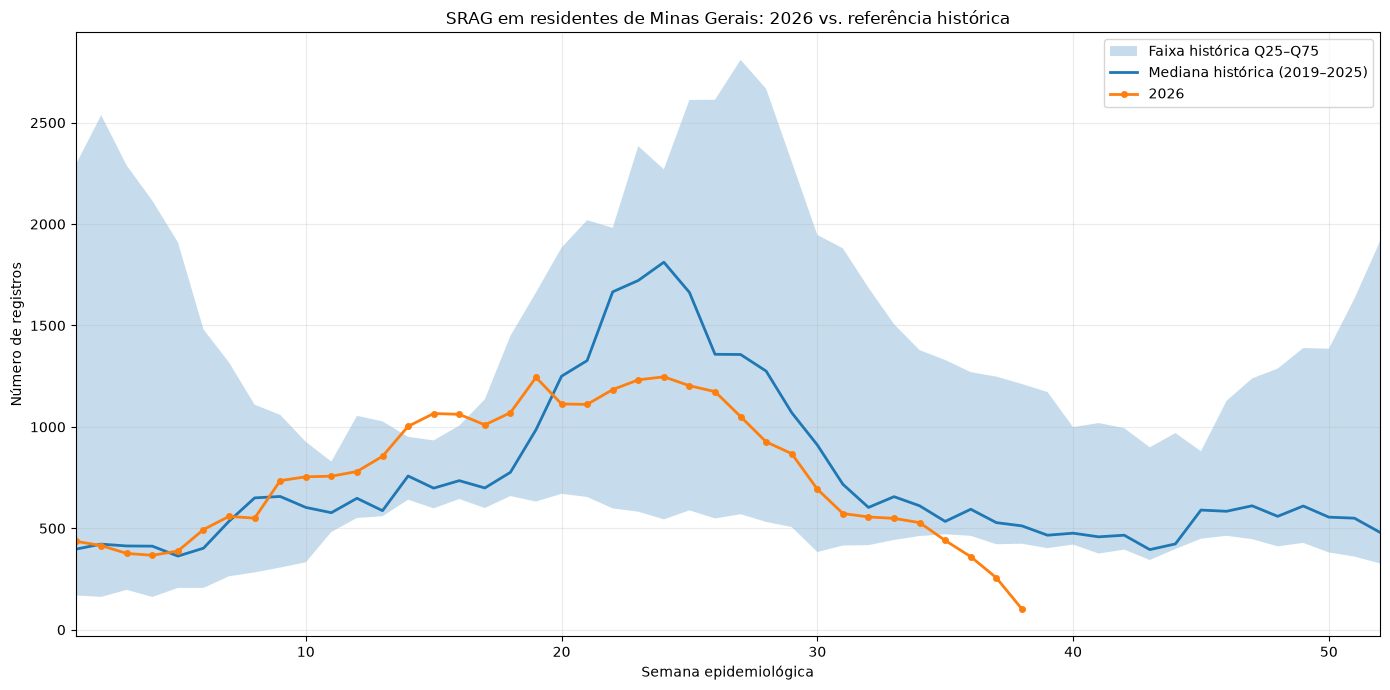

In [34]:
fig, ax = plt.subplots(figsize=(14, 7))

ax.fill_between(
    historical_reference["epi_week"],
    historical_reference["q25"],
    historical_reference["q75"],
    alpha=0.25,
    label="Faixa histórica Q25–Q75",
)

ax.plot(
    historical_reference["epi_week"],
    historical_reference["historical_median"],
    linewidth=2,
    label="Mediana histórica (2019–2025)",
)

ax.plot(
    comparison_2026["epi_week"],
    comparison_2026["record_count"],
    linewidth=2,
    marker="o",
    markersize=4,
    label="2026",
)

ax.set_title(
    "SRAG em residentes de Minas Gerais: 2026 vs. referência histórica"
)

ax.set_xlabel("Semana epidemiológica")
ax.set_ylabel("Número de registros")

ax.set_xlim(1, 52)

ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()

## Requisitos mínimos da referência histórica

A referência histórica adotada utiliza a mediana da contagem de registros
para cada semana epidemiológica, acompanhada pelos percentis 25 e 75 como
medidas descritivas de dispersão.

Para que uma semana seja considerada válida na referência histórica,
devem ser atendidos os seguintes requisitos:

1. O registro deve possuir data de início dos sintomas (`DT_SIN_PRI`)
   válida.

2. A região deve ser definida pela UF de residência (`SG_UF`), normalizada
   antes da seleção dos registros de Minas Gerais.

3. A semana epidemiológica deve ser calculada a partir de `DT_SIN_PRI`
   utilizando a mesma regra de calendário aplicada à série corrente.

4. Apenas anos anteriores ao ano corrente podem participar da referência.
   O ano analisado não pode contribuir para sua própria referência.

5. Cada semana da referência deve possuir observações históricas de pelo
   menos 3 anos distintos.

6. A referência principal é limitada às semanas epidemiológicas 1 a 52.
   A semana 53 deve ser tratada separadamente quando existente, pois não
   está presente em todos os anos.

7. Ausência de cobertura não deve ser interpretada como contagem zero.
   Zero somente representa uma semana coberta na qual nenhum registro
   elegível foi encontrado.

8. Q25 e Q75 são utilizados apenas para descrever a dispersão histórica.
   Eles não constituem, nesta etapa, limites epidemiológicos de alerta,
   surto ou anomalia.

In [35]:
MIN_HISTORICAL_YEARS = 3

historical_reference["has_minimum_history"] = (
    historical_reference["historical_years"]
    >= MIN_HISTORICAL_YEARS
)

assert historical_reference[
    "has_minimum_history"
].all()

print(
    "Semanas com histórico mínimo:",
    historical_reference["has_minimum_history"].sum(),
    "/",
    len(historical_reference),
)

print(
    "Anos históricos por semana:",
    historical_reference["historical_years"].min(),
    "a",
    historical_reference["historical_years"].max(),
)

Semanas com histórico mínimo: 52 / 52
Anos históricos por semana: 7 a 7


## Pressupostos e limitações

### Pressupostos

A referência histórica parte dos seguintes pressupostos:

- `DT_SIN_PRI` é a referência temporal do indicador e representa a data de
  início dos sintomas utilizada para posicionar cada registro na série.

- `SG_UF` é utilizada como referência geográfica de residência. Portanto,
  a análise representa registros de residentes de Minas Gerais, e não
  necessariamente registros notificados ou internados no estado.

- A semana epidemiológica é calculada a partir de `DT_SIN_PRI` utilizando
  a mesma regra de calendário da série corrente. O campo `SEM_PRI` da
  fonte não é utilizado diretamente na construção da referência.

- Os anos de 2019 a 2025 constituem o histórico disponível para comparação
  com 2026.

- Cada semana epidemiológica é comparada com a mesma semana dos anos
  históricos, preservando a sazonalidade da série.

### Limitações

- O período histórico apresenta forte heterogeneidade entre os anos.
  Os volumes e os padrões semanais observados em 2020, 2021 e 2022 foram
  substancialmente diferentes de outros anos do histórico.

- A mediana reduz a influência de valores extremos, mas não elimina
  diferenças estruturais entre os anos.

- A referência utiliza somente sete anos históricos. Portanto, os
  percentis calculados possuem quantidade limitada de observações por
  semana.

- Q25 e Q75 representam apenas a dispersão central dos valores históricos.
  Eles não devem ser interpretados como limites de alerta epidemiológico,
  surto ou anomalia.

- Mudanças na vigilância, definição de casos, comportamento de procura por
  atendimento, capacidade de diagnóstico e qualidade da notificação podem
  afetar a comparabilidade entre anos.

- A semana epidemiológica 53 não participa da referência principal, pois
  não ocorre em todos os anos analisados. A referência padrão considera
  as semanas 1 a 52.

- Dados de vigilância podem sofrer inclusões e revisões posteriores.
  Uma semana encerrada no calendário não implica dados definitivos.

- Ausência de cobertura não é equivalente a zero registros. Valores iguais
  a zero somente devem ser utilizados quando a semana estiver coberta e
  nenhum registro elegível for encontrado.

### Uso da referência

Nesta etapa, a referência histórica tem finalidade descritiva e
comparativa.

Ela permite contextualizar o comportamento da série corrente em relação
ao histórico, mas não define, isoladamente, critérios para geração de
alertas epidemiológicos.

In [36]:
reference_path = (
    project_root
    / "data"
    / "processed"
    / "srag_mg_historical_reference_2019_2025.csv"
)

historical_reference.to_csv(
    reference_path,
    sep=";",
    index=False,
    encoding="utf-8",
)

print(f"Referência histórica salva em: {reference_path}")

Referência histórica salva em: /home/matheuspessoa/Sentinela/data/processed/srag_mg_historical_reference_2019_2025.csv
